# Feishu model comparison — trend classification (A-share equities)

Compares the trend classifiers on the Feishu 5-min LOB data (OFI features), on a
**shared test set** built once for all models. This notebook is deliberately
**results-only** — accuracy / F1 / confusion / per-asset / robustness — with no
financial-backtest or statistical-significance layer (see the crypto notebook for
those).

| tag | class | family |
|-----|-------|--------|
| `logreg` | `LogReg` | linear (flattened-window softmax) |
| `linvar` | `LinVAR` | linear recurrent (VAR-style) |
| `deeplob` | `DeepLOB` | CNN + inception + LSTM |
| `ctabl` | `CTABL` | bilinear temporal attention |
| `dla` | `DLA` | dual-stage attention enc–dec |
| `tlob` | `TLOB` | temporal/spatial transformer |
| `jumpgatelob` | `JumpGateLOB` | jump-diffusion score matching |
| `alphastablelob` | `AlphaStableLOB` | α-stable joint diffusion-classifier |

**Sections**
1. Setup
2. Config & checkpoint registry (variant: 20-asset or all-asset runs)
3. Build shared test set + evaluate every model
4. Overall metrics (accuracy / macro-F1 / per-class F1)
5. Confusion matrices
6. Per-asset comparison (accuracy heatmap, uniform vs noisy groups)
7. Robustness under injected input noise (gaussian / jump / student_t / alpha_stable)

> Run from the **Penny repo root** so `data/stocks/feishu` and `checkpoints/` resolve.

## 1. Setup

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
from torch.utils.data import DataLoader, Subset

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"could not find Penny repo root above {start}")


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from stocks.feishu.build import build_datasets_multi  # noqa: E402
from stocks.feishu.features import n_features as feishu_n_features  # noqa: E402
from models.deeplob import DeepLOB  # noqa: E402
from models.ctabl import CTABL  # noqa: E402
from models.dla import DLA  # noqa: E402
from models.tlob import TLOB  # noqa: E402
from models.linvar import LinVAR  # noqa: E402
from models.logreg import LogReg  # noqa: E402
from models.jumpgatelob import JumpGateLOB  # noqa: E402
from models.alphastablelob import AlphaStableLOB  # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Config & checkpoint registry

`VARIANT` selects which trained runs to compare: `"20_assets"` (models trained on
the 20 selected high-volume assets) or `"all"` (whole universe). `SYMBOLS` is the
asset universe the shared test set is built over — the 10 *uniform* + 10 *noisy*
high-volume names from the volume/uniformity analysis. Edit if your run used a
different set.

In [2]:
BATCH = 256
VARIANT = "20_assets"          # "20_assets" | "all"  (which checkpoint variant to load)

# high-volume asset groups (from the volume / trading-uniformity analysis)
UNIFORM_10 = ["A002059", "A001750", "A000863", "A000369", "A001402",
              "A001472", "A001351", "A001438", "A000956", "A000613"]
NOISY_10 = ["A002000", "A000295", "A001748", "A002042", "A000400",
            "A000875", "A000452", "A001208", "A002142", "A001663"]
GROUP = {**{s: "uniform" for s in UNIFORM_10}, **{s: "noisy" for s in NOISY_10}}
SYMBOLS = UNIFORM_10 + NOISY_10

MODELS = {
    "logreg": LogReg, "linvar": LinVAR, "deeplob": DeepLOB, "ctabl": CTABL,
    "dla": DLA, "tlob": TLOB, "jumpgatelob": JumpGateLOB,
    "alphastablelob": AlphaStableLOB,
}
DISPLAY = {m: m for m in MODELS}
LABELS = ["down", "stationary", "up"]
CKPT_ROOT = REPO / "checkpoints" / "stocks" / "feishu"


def discover_checkpoints() -> dict:
    """tag -> newest run dir matching VARIANT with a best.pt."""
    found = {}
    for tag in MODELS:
        d = CKPT_ROOT / tag
        if not d.exists():
            continue
        runs = sorted(
            p for p in d.iterdir()
            if p.is_dir() and p.name.endswith(VARIANT) and (p / "best.pt").exists()
        )
        if runs:
            found[tag] = runs[-1]
    return found


CHECKPOINTS = discover_checkpoints()
print(f"variant={VARIANT}  |  {len(SYMBOLS)} assets  |  discovered checkpoints:")
for tag in MODELS:
    hit = CHECKPOINTS.get(tag)
    print(f"  {tag:<16} {'✓ ' + hit.name if hit else '— missing'}")

variant=20_assets  |  20 assets  |  discovered checkpoints:
  logreg           ✓ logreg_ofi_20_assets
  linvar           ✓ linvar_ofi_20_assets
  deeplob          ✓ deeplob_ofi_20_assets
  ctabl            ✓ ctabl_ofi_20_assets
  dla              ✓ dla_ofi_20_assets
  tlob             ✓ tlob_ofi_20_assets
  jumpgatelob      ✓ jumpgatelob_levy_ofi_20_assets
  alphastablelob   ✓ alphastablelob_joint_a1.5_ofi_20_assets


## 3. Build shared test set + evaluate every model

The test set (last-15% chronological slice per asset) is built **once** with
`build_datasets_multi`, so every model is scored on identical windows/labels, and
each window carries its `asset` id for the per-asset breakdown.

In [3]:
def load_ckpt(path: Path) -> dict:
    return torch.load(Path(path) / "best.pt", map_location=DEVICE, weights_only=False)


def build_model(tag: str, ckpt: dict):
    model = MODELS[tag](ckpt["config"]).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model


@torch.no_grad()
def evaluate(model, ds):
    loader = DataLoader(ds, batch_size=BATCH, shuffle=False)
    yt, yp, pr, ast = [], [], [], []
    for b in loader:
        logits = model.predict(b, DEVICE)
        pr.append(Fn.softmax(logits, 1).cpu().numpy())
        yp.append(logits.argmax(1).cpu().numpy())
        yt.append(b["label"].numpy())
        ast.append(b["asset"].numpy())
    return (np.concatenate(yt), np.concatenate(yp),
            np.concatenate(pr), np.concatenate(ast))


# base config from any discovered run (all share T_past / alpha / n_features)
assert CHECKPOINTS, "no checkpoints discovered — check VARIANT / CKPT_ROOT"
_base = load_ckpt(next(iter(CHECKPOINTS.values())))["config"].copy()
_base["batch_size"] = BATCH
DATA_DIR = _base["data_dir"]
print(f"building shared test set: T_past={_base['T_past']} alpha={_base['alpha']} "
      f"nf={_base.get('n_features')}  data_dir={DATA_DIR}")

_, _, test_ds, META = build_datasets_multi(_base, DATA_DIR, SYMBOLS)
SYMS = META["symbols"]
print(f"test windows: {len(test_ds)}  |  assets: {META['n_assets']}")

# RESULTS[tag] = {"y_true","y_pred","probs","asset"}
RESULTS = {}
for tag in MODELS:
    hit = CHECKPOINTS.get(tag)
    if not hit:
        print(f"  {tag:<16} — no checkpoint, skipped")
        continue
    ckpt = load_ckpt(hit)
    if ckpt["config"].get("T_past") != _base["T_past"]:
        print(f"  {tag:<16} ! T_past mismatch, skipped")
        continue
    model = build_model(tag, ckpt)
    yt, yp, pr, ast = evaluate(model, test_ds)
    RESULTS[tag] = {"y_true": yt, "y_pred": yp, "probs": pr, "asset": ast}
    acc = (yt == yp).mean()
    f1 = f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0)
    print(f"  {tag:<16} acc={acc:.4f}  macro_f1={f1:.4f}")
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
print(f"\nevaluated {len(RESULTS)} models on the shared test set")

2026-07-18 17:52:13.045 | INFO     | stocks.feishu.build:_build_feature_matrix:144 - building feishu features (RAM) mode=OFI nf=259


building shared test set: T_past=50 alpha=0.015 nf=259  data_dir=data/stocks/feishu


2026-07-18 17:52:57.843 | INFO     | stocks.feishu.build:_build_feature_matrix:254 - feishu features built (in RAM): 9,680 rows × 259 feat
2026-07-18 17:52:57.845 | INFO     | stocks.feishu.build:build_datasets_multi:390 - multi windows — train:6060 val:1300 test:1300 n_assets:20


test windows: 1300  |  assets: 20
  logreg           acc=0.3592  macro_f1=0.3446
  linvar           acc=0.4238  macro_f1=0.3660
  deeplob          acc=0.4431  macro_f1=0.2047
  ctabl            acc=0.4515  macro_f1=0.3283
  dla              acc=0.4431  macro_f1=0.2047
  tlob             acc=0.2692  macro_f1=0.2014
  jumpgatelob      acc=0.4677  macro_f1=0.3610
  alphastablelob   acc=0.4492  macro_f1=0.3754

evaluated 8 models on the shared test set


## 4. Overall metrics

,accuracy,macro_f1,f1_down,f1_stat,f1_up
model,,,,,
logreg,0.3592,0.3446,0.3236,0.4548,0.2553
linvar,0.4238,0.3660,0.3105,0.5684,0.2190
deeplob,0.4431,0.2047,0.0000,0.6141,0.0000
ctabl,0.4515,0.3283,0.2591,0.6072,0.1187
dla,0.4431,0.2047,0.0000,0.6141,0.0000
tlob,0.2692,0.2014,0.0000,0.2334,0.3709
jumpgatelob,0.4677,0.3610,0.3449,0.6229,0.1151
alphastablelob,0.4492,0.3754,0.3044,0.6000,0.2218


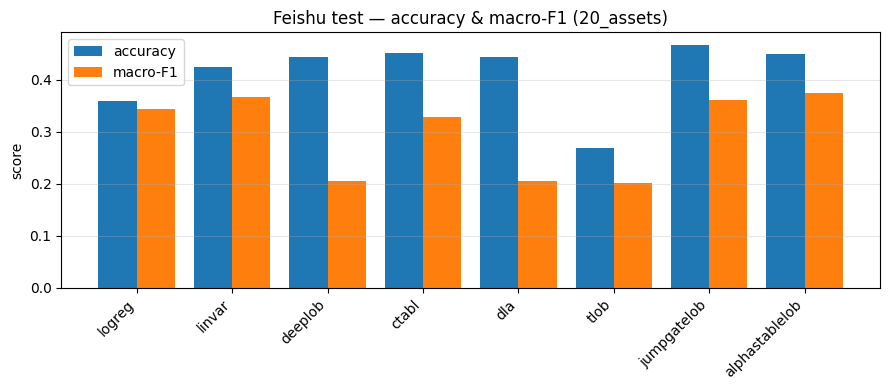

In [4]:
def metrics_row(yt, yp):
    per = f1_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    return {
        "accuracy": (yt == yp).mean(),
        "macro_f1": f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0),
        "f1_down": per[0], "f1_stat": per[1], "f1_up": per[2],
    }


rows = [{"model": DISPLAY[t], **metrics_row(r["y_true"], r["y_pred"])}
        for t, r in RESULTS.items()]
metrics_df = pd.DataFrame(rows)
if not metrics_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    metrics_df = metrics_df.set_index("model").reindex(order)
    display(metrics_df.style.background_gradient(cmap="YlGn", axis=0).format("{:.4f}"))

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(metrics_df))
    ax.bar(x - 0.2, metrics_df["accuracy"], 0.4, label="accuracy")
    ax.bar(x + 0.2, metrics_df["macro_f1"], 0.4, label="macro-F1")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df.index, rotation=45, ha="right")
    ax.set_ylabel("score")
    ax.set_title(f"Feishu test — accuracy & macro-F1 ({VARIANT})")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("No results — populate CHECKPOINTS in section 2 and re-run.")

## 5. Confusion matrices

Row-normalized (recall per true class). A model collapsing to one column (a single
predicted class) is immediately visible as one bright column.

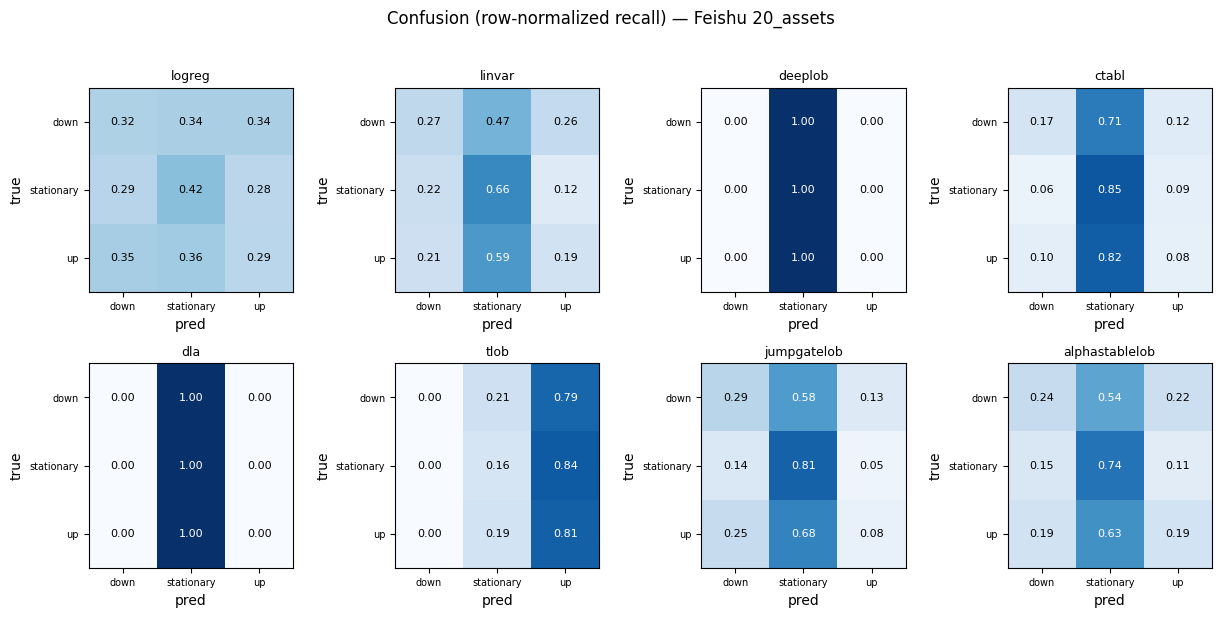

In [5]:
tags = [t for t in MODELS if t in RESULTS]
if tags:
    ncol = min(4, len(tags))
    nrow = int(np.ceil(len(tags) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 3.0 * nrow), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, tag in zip(axes.flat, tags):
        ax.axis("on")
        r = RESULTS[tag]
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=[0, 1, 2]).astype(float)
        cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
        ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center",
                        fontsize=8, color="white" if cmn[i, j] > 0.5 else "black")
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(LABELS, fontsize=7); ax.set_yticklabels(LABELS, fontsize=7)
        ax.set_title(DISPLAY[tag], fontsize=9)
        ax.set_xlabel("pred"); ax.set_ylabel("true")
    fig.suptitle(f"Confusion (row-normalized recall) — Feishu {VARIANT}", y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Per-asset comparison

Accuracy per (model, asset). Assets are ordered **uniform group then noisy group**
(the volume/uniformity split), so you can read directly whether a model holds up on
the bursty/noisy names as well as the calm ones — the property the diffusion models
target.

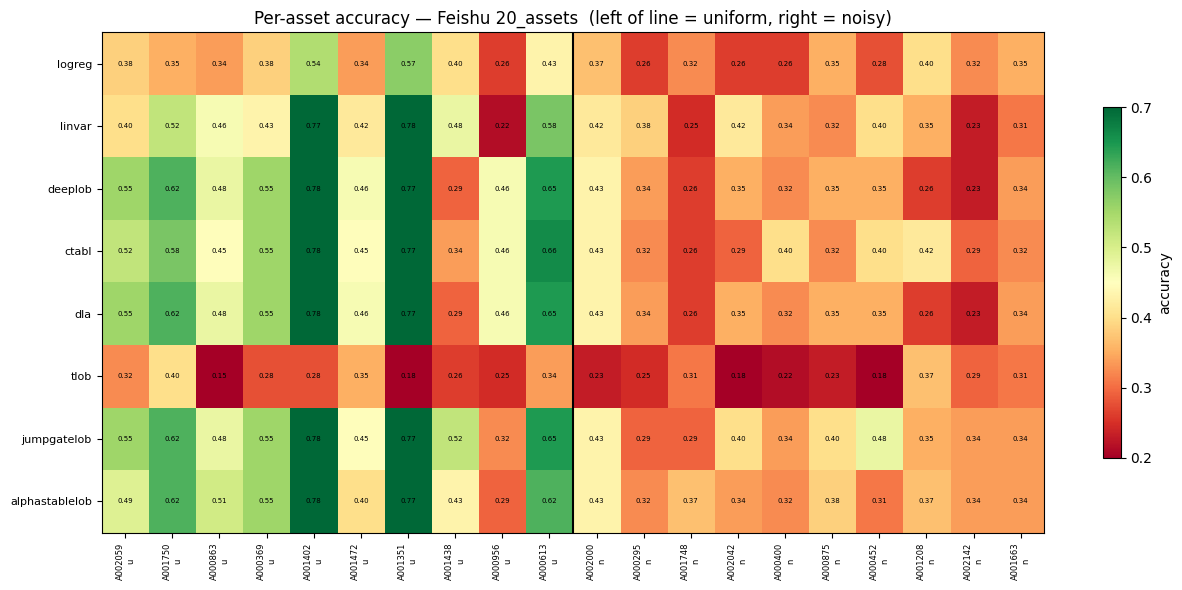

Mean accuracy by asset group (Δ small ⇒ robust across trading regimes):


,uniform,noisy,Δ (uniform−noisy)
logreg,0.4000,0.3185,0.0815
linvar,0.5062,0.3415,0.1646
deeplob,0.5615,0.3246,0.2369
ctabl,0.5569,0.3462,0.2108
dla,0.5615,0.3246,0.2369
tlob,0.2815,0.2569,0.0246
jumpgatelob,0.5692,0.3662,0.2031
alphastablelob,0.5462,0.3523,0.1938


In [6]:
def per_asset_accuracy(tag):
    r = RESULTS[tag]
    out = {}
    for a in range(len(SYMS)):
        m = r["asset"] == a
        out[SYMS[a]] = float((r["y_true"][m] == r["y_pred"][m]).mean()) if m.any() else np.nan
    return out


tags = [t for t in MODELS if t in RESULTS]
if tags:
    # asset order: uniform block then noisy block (only those present in SYMS)
    asset_order = [s for s in UNIFORM_10 + NOISY_10 if s in SYMS]
    acc = pd.DataFrame({DISPLAY[t]: per_asset_accuracy(t) for t in tags}).T
    acc = acc[asset_order]

    fig, ax = plt.subplots(figsize=(0.5 * len(asset_order) + 3, 0.5 * len(tags) + 2))
    im = ax.imshow(acc.values, cmap="RdYlGn", vmin=0.2, vmax=0.7, aspect="auto")
    ax.set_xticks(range(len(asset_order)))
    ax.set_xticklabels([f"{s}\n{GROUP.get(s, '')[:1]}" for s in asset_order],
                       rotation=90, fontsize=6)
    ax.set_yticks(range(len(tags)))
    ax.set_yticklabels([DISPLAY[t] for t in tags], fontsize=8)
    # divider between uniform and noisy blocks
    n_uni = sum(1 for s in asset_order if GROUP.get(s) == "uniform")
    if 0 < n_uni < len(asset_order):
        ax.axvline(n_uni - 0.5, color="black", lw=1.5)
    for i in range(len(tags)):
        for j in range(len(asset_order)):
            v = acc.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5,
                        color="black")
    fig.colorbar(im, shrink=0.7, label="accuracy")
    ax.set_title(f"Per-asset accuracy — Feishu {VARIANT}  "
                 f"(left of line = uniform, right = noisy)")
    plt.tight_layout()
    plt.show()

    # group means: does each model degrade on the noisy block?
    grp = pd.DataFrame({
        "uniform": acc[[s for s in asset_order if GROUP.get(s) == "uniform"]].mean(1),
        "noisy": acc[[s for s in asset_order if GROUP.get(s) == "noisy"]].mean(1),
    })
    grp["Δ (uniform−noisy)"] = grp["uniform"] - grp["noisy"]
    print("Mean accuracy by asset group (Δ small ⇒ robust across trading regimes):")
    display(grp.style.background_gradient(cmap="RdYlGn", subset=["uniform", "noisy"])
            .format("{:.4f}"))

## 7. Robustness under injected input noise

Take clean test windows and inject increasing noise ourselves — identically for
every model — then watch macro-F1 fall off. Four corruptions at overall scale `σ`
(features are z-scored, so `σ≈1` is heavy):

- **gaussian** — `x + σ·ξ` (light-tailed baseline).
- **jump** — the JumpGateLOB kernel (Gaussian scale mixture + compound-Poisson jumps).
- **student_t** — heavy-tailed Student-t (ν=3, unit-variance); **neither** diffusion
  model's training kernel → the fairest *unseen heavy-tail* stress test.
- **alpha_stable** — the AlphaStableLOB kernel (subordinated-Gaussian α-stable, α=1.7).

Flatter curves = more robust. Same fair-test caveat as the crypto notebook: the
diffusion models trained on heavy-tailed kernels while the others never saw injected
noise, so a win reads as *corruption-aware-training robustness*, not architecture.

In [7]:
# --- noise sweep config (reduce ROBUST_N / ROBUST_SIGMAS if too slow) ---------
ROBUST_N = 2500  # test windows subsampled
ROBUST_SIGMAS = [0.0, 0.15, 0.3, 0.5, 0.75, 1.0]  # overall noise scale σ
ROBUST_KINDS = ["gaussian", "jump", "student_t", "alpha_stable"]
SIGMA_FOCUS = 0.5  # σ at which calibration / probs are inspected
JUMP = {"rate": 1.0, "shape": 1.0, "scale": 1.0}  # JumpGateLOB levy kernel
STUDENT_NU = 3.0  # Student-t degrees of freedom (heavier as ν→2); var = ν/(ν-2)
ASTABLE_ALPHA = 1.7  # α-stable stability index (α<2 ⇒ power-law tails)
ASTABLE_CLIP_Q = 0.999  # clip the (infinite-mean) subordinator for stability


def perturb(x, sigma, kind, seed):
    """Deterministic input corruption (identical across models given the seed).

    gaussian     — x + σ·ξ                       (light-tailed baseline)
    jump         — x + √W·ξ, W=σ²+ΣGamma jumps   (JumpGateLOB kernel; discrete)
    student_t    — x + σ·t_ν  (ν=3, unit-var)    (heavy-tailed; *neither* kernel)
    alpha_stable — x + √W·ξ, W=σ²·A, A~S⁺_{α/2}  (AlphaStableLOB kernel; power-law)
    """
    torch.manual_seed(seed)  # reproducible randn + _standard_gamma
    eps = torch.randn_like(x)
    if sigma == 0.0 or kind == "gaussian":
        return x + sigma * eps
    v = (-1,) + (1,) * (x.dim() - 1)

    if kind == "jump":
        b = x.shape[0]
        W = torch.full((b,), sigma * sigma)
        N = torch.poisson(torch.full((b,), JUMP["rate"] * sigma))
        m = N > 0
        if m.any():
            W = W.clone()
            W[m] = W[m] + torch._standard_gamma(N[m] * JUMP["shape"]) * JUMP["scale"]
        return x + W.sqrt().view(v) * eps

    if kind == "student_t":
        # standardised Student-t (unit variance for ν>2) → comparable to gaussian σ
        chi2 = torch._standard_gamma(torch.full_like(x, STUDENT_NU / 2.0)) * 2.0
        t = eps / (chi2 / STUDENT_NU).sqrt()
        t = t * ((STUDENT_NU - 2.0) / STUDENT_NU) ** 0.5
        return x + sigma * t

    if kind == "alpha_stable":
        # positive (β=α/2)-stable subordinator A via Kanter (1975); W = σ²·A
        b = x.shape[0]
        beta = ASTABLE_ALPHA / 2.0
        U = torch.rand(b).clamp(1e-7, 1 - 1e-7) * float(np.pi)
        E = (-torch.log(torch.rand(b).clamp_min(1e-12))).clamp_min(1e-12)
        t1 = torch.sin(beta * U) / torch.sin(U).clamp_min(1e-12).pow(1.0 / beta)
        t2 = (torch.sin((1 - beta) * U) / E).clamp_min(1e-30).pow((1 - beta) / beta)
        A = (t1 * t2).clamp_min(1e-12)
        A = A.clamp_max(torch.quantile(A, ASTABLE_CLIP_Q))
        W = (sigma * sigma) * A
        return x + W.sqrt().view(v) * eps

    raise ValueError(f"unknown kind {kind!r}")


@torch.no_grad()
def run_robust_sweep():
    """macro-F1 vs σ for every (model, kind) on a shared subsample of the test set."""
    rng = np.random.default_rng(0)
    idx = np.sort(rng.choice(len(test_ds), min(ROBUST_N, len(test_ds)), replace=False))
    sub = Subset(test_ds, idx.tolist())
    rows = []
    for tag in MODELS:
        hit = CHECKPOINTS.get(tag)
        if not hit:
            continue
        model = build_model(tag, load_ckpt(hit))
        for kind in ROBUST_KINDS:
            loader = DataLoader(sub, batch_size=BATCH, shuffle=False)
            for sig in ROBUST_SIGMAS:
                yt, yp = [], []
                for bi, b in enumerate(loader):
                    x = b["x"].float()
                    seed = int(sig * 1000) + bi * 7 + ROBUST_KINDS.index(kind) * 100003
                    xp = perturb(x, sig, kind, seed)
                    logits = model.predict({"x": xp, "label": b["label"]}, DEVICE)
                    yp.append(logits.argmax(1).cpu().numpy())
                    yt.append(b["label"].numpy())
                yt, yp = np.concatenate(yt), np.concatenate(yp)
                rows.append({
                    "model": DISPLAY[tag], "kind": kind, "sigma": sig,
                    "macro_f1": f1_score(yt, yp, average="macro", labels=[0, 1, 2],
                                         zero_division=0),
                })
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"  swept {tag}")
    return pd.DataFrame(rows)


print(f"running noise sweep — {ROBUST_N} windows × {len(ROBUST_SIGMAS)} σ × "
      f"{len(ROBUST_KINDS)} kinds…")
robust_df = run_robust_sweep()
print(f"done — {len(robust_df)} rows")

running noise sweep — 2500 windows × 6 σ × 4 kinds…
  swept logreg
  swept linvar
  swept deeplob
  swept ctabl
  swept dla
  swept tlob
  swept jumpgatelob
  swept alphastablelob
done — 192 rows


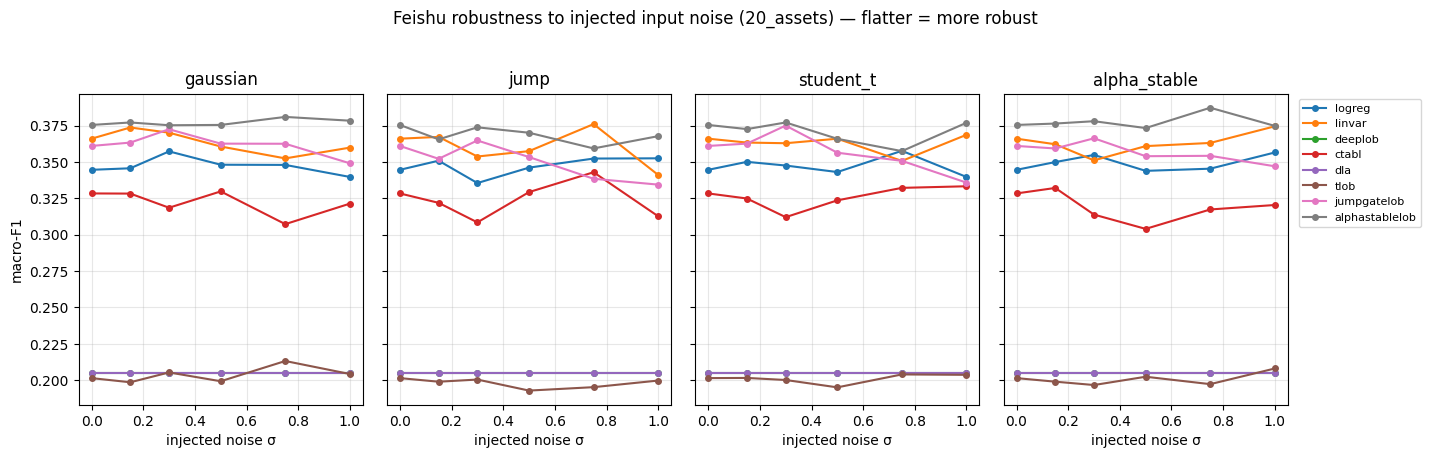

Retention  F1(σ=1.0)/F1(0)  by corruption (higher = more robust):


kind,gaussian,jump,student_t,alpha_stable,mean
model,,,,,
tlob,1.014,0.992,1.011,1.033,1.012
logreg,0.986,1.023,0.986,1.035,1.007
deeplob,1.000,1.000,1.000,1.000,1.000
dla,1.000,1.000,1.000,1.000,1.000
alphastablelob,1.008,0.979,1.004,0.998,0.997
linvar,0.983,0.932,1.007,1.023,0.986
ctabl,0.979,0.952,1.015,0.976,0.980
jumpgatelob,0.967,0.926,0.930,0.961,0.946


In [8]:
# macro-F1 vs σ — one panel per noise kind
if not robust_df.empty:
    cmap = plt.get_cmap("tab10")
    present = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(robust_df["model"])]
    n = len(ROBUST_KINDS)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 4.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, kind in zip(axes, ROBUST_KINDS):
        d = robust_df[robust_df["kind"] == kind]
        for i, name in enumerate(present):
            m = d[d["model"] == name].sort_values("sigma")
            ax.plot(m["sigma"], m["macro_f1"], "o-", ms=4, color=cmap(i % 10), label=name)
        ax.set_xlabel("injected noise σ")
        ax.set_title(f"{kind}")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("macro-F1")
    axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.suptitle(f"Feishu robustness to injected input noise ({VARIANT}) — "
                 f"flatter = more robust", y=1.03)
    plt.tight_layout()
    plt.show()

    # retention = F1(σ_max)/F1(0) per corruption; higher = more robust
    hi = robust_df["sigma"].max()
    base = robust_df[robust_df["sigma"] == 0.0].set_index(["model", "kind"])["macro_f1"]
    top = robust_df[robust_df["sigma"] == hi].set_index(["model", "kind"])["macro_f1"]
    ret = (top / base.clip(lower=1e-9)).rename("retention").reset_index()
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(ret["model"])]
    piv = ret.pivot(index="model", columns="kind", values="retention").reindex(order)
    piv = piv[[k for k in ROBUST_KINDS if k in piv.columns]]
    piv["mean"] = piv.mean(axis=1)
    print(f"Retention  F1(σ={hi})/F1(0)  by corruption (higher = more robust):")
    display(piv.sort_values("mean", ascending=False)
            .style.background_gradient(cmap="YlGn", axis=None).format("{:.3f}"))